# Joint DANN eval — Lipschitz encoder + MAF5, v3.1

Evaluates `exp-v3.1_encoder-lipschitz_dann_flow-maf5`: 1M sims, WDGRL (λ=0.5, 100-ep ramp),
Mixup real augmentation, 600 epochs. Final: task=-3.01, w1=0.57.

1. **Training curves** — task loss, W1, lambda
2. **Latent space** — PCA/UMAP: encoder(sim) vs encoder(real)
3. **Direct inference** — sample flow on real patients
4. **Parameter scatter** — posterior mean vs GT (Rap/PVR, Ras/SVR)
5. **Real patient calibration** — credible interval coverage for Rap and Ras
6. **PAH vs controls** — key parameter estimates
7. **Sim evaluation** — scatter, error metrics, calibration for all 24 params

In [1]:
import json, sys, h5py, csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

try:
    ROOT = Path(globals()['_dh'][0]).parent
    assert (ROOT / 'dataset.py').exists()
except:
    ROOT = Path('/home/sa4604/cv-dann-sbi')
sys.path.insert(0, str(ROOT))

from dataset import (
    load_stats, load_manifest, ReducedCVDataset,
    PARAM_KEYS_INFER, N_CHANNELS, T, WAVE_KEYS_CONT,
)
from models import LipschitzReducedAutoencoderEncoder

WAVE_KEYS_REAL = ['Prv', 'Pra', 'Pvp', 'Pap']

device = torch.device('cuda:0')
print('device:', device)

device: cuda:0


In [2]:
RUN        = 'exp-v3.1_encoder-lipschitz_dann_flow-maf5'
VERSION    = '3.1'
RUN_DIR    = ROOT / f'outputs/{RUN}'

REAL_DATA  = Path('/home/sa4604/real_data/onebeat_300patients')
SIM_ROOT   = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314')
STATS_PATH = ROOT / 'norm_stats.json'

N_POSTERIOR_SAMPLES = 1000
N_SIM_PCA           = 500

stats    = load_stats(STATS_PATH)
manifest = load_manifest(SIM_ROOT / 'manifest_train.json')
lo_t = torch.tensor([manifest['config']['pvar_low'][k]  for k in PARAM_KEYS_INFER], dtype=torch.float32)
hi_t = torch.tensor([manifest['config']['pvar_high'][k] for k in PARAM_KEYS_INFER], dtype=torch.float32)
print('Prior bounds loaded for', len(PARAM_KEYS_INFER), 'parameters')

Prior bounds loaded for 24 parameters


## Training curves

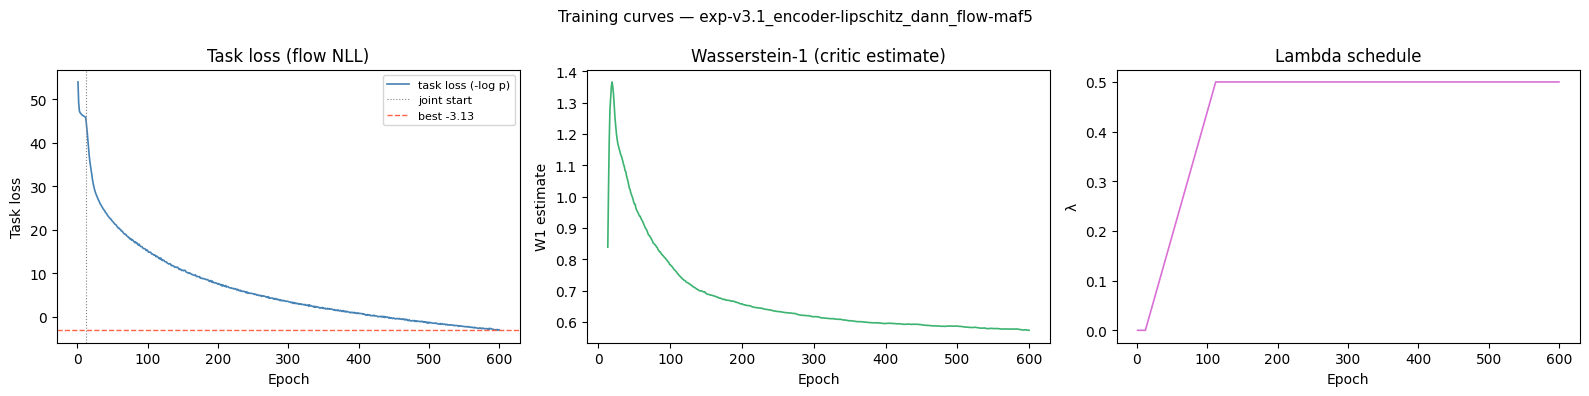

Total epochs: 600  best task (joint): -3.1286  final W1: 0.5731


In [3]:
csv_files = sorted(RUN_DIR.glob('train_log_*.csv'))
assert csv_files, f'No train_log CSV in {RUN_DIR}'

epochs, task_l, w1_l, gp_l, lam_l, phase_l = [], [], [], [], [], []
with open(csv_files[-1]) as f:
    for row in csv.DictReader(f):
        epochs.append(int(row['epoch']))
        task_l.append(float(row['task']))
        w1_l.append(float(row['w1_est']))
        gp_l.append(float(row['gp']))
        lam_l.append(float(row['lambda']))
        phase_l.append(int(row['phase']))

epochs = np.array(epochs)
joint_start = next(i for i, p in enumerate(phase_l) if p == 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(epochs, task_l, color='steelblue', linewidth=1.2, label='task loss (-log p)')
ax.axvline(epochs[joint_start], color='grey', linestyle=':', linewidth=0.8, label='joint start')
best_task = min(task_l[joint_start:])
ax.axhline(best_task, color='tomato', linestyle='--', linewidth=1, label=f'best {best_task:.2f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Task loss'); ax.set_title('Task loss (flow NLL)')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(epochs[joint_start:], w1_l[joint_start:], color='mediumseagreen', linewidth=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('W1 estimate'); ax.set_title('Wasserstein-1 (critic estimate)')

ax = axes[2]
ax.plot(epochs, lam_l, color='orchid', linewidth=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('λ'); ax.set_title('Lambda schedule')

fig.suptitle(f'Training curves — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Total epochs: {len(epochs)}  best task (joint): {best_task:.4f}  final W1: {w1_l[-1]:.4f}')

## Load models

In [4]:
encoder = LipschitzReducedAutoencoderEncoder(latent_dim=128).to(device)
encoder.load_state_dict(torch.load(RUN_DIR / 'encoder.pt', map_location=device))
encoder.eval()
print('Encoder loaded:', encoder.describe())

flow_net = torch.load(RUN_DIR / 'flow_net.pt', map_location=device, weights_only=False)
flow_net.eval()
print('Flow loaded:', type(flow_net).__name__)

Encoder loaded: {'type': 'LipschitzReducedAutoencoderEncoder', 'input_waveforms': '(4, 201)', 'input_scalars': 'Pas_mean, Pas_max, Pas_min, SV, HR_z', 'latent_dim': 128, 'proj_hidden': None, 'sn_ceiling': 2.0, 'n_params': 439617}
Flow loaded: NFlowsFlow


/home/sa4604/cv-dann-sbi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load real patients

In [5]:
w = stats['waves']
p = stats['parameters']
wave_mean = torch.tensor([w[k]['mean'] for k in WAVE_KEYS_REAL], dtype=torch.float32).unsqueeze(1)
wave_std  = torch.tensor([w[k]['std']  for k in WAVE_KEYS_REAL], dtype=torch.float32).unsqueeze(1)
pas_mean, pas_std = w['Pas']['mean'], w['Pas']['std'] + 1e-8
vlv_std           = w['Vlv']['std'] + 1e-8
hr_mean,  hr_std  = p['HR']['mean'],  p['HR']['std']  + 1e-8

patients = []
for fpath in sorted(REAL_DATA.glob('*.h5')):
    beats_x, gt = [], {}
    with h5py.File(fpath, 'r') as f:
        for bk in sorted(f.keys()):
            if not bk.startswith('beat_'): continue
            g = f[bk]
            waves = np.stack([g[f'waves/{k}'][:].astype(np.float32) for k in WAVE_KEYS_REAL])
            wt    = (torch.from_numpy(waves) - wave_mean) / (wave_std + 1e-8)
            sbp   = float(g['summaries/sbp'][()])
            dbp   = float(g['summaries/dbp'][()])
            map_  = float(g['summaries/map'][()])
            sv    = float(g['summaries/sv'][()])
            hr    = float(g['parameters/HR'][()])
            sc = torch.tensor([
                (map_ - pas_mean) / pas_std,
                (sbp  - pas_mean) / pas_std,
                (dbp  - pas_mean) / pas_std,
                sv    / vlv_std,
                (hr   - hr_mean)  / hr_std,
            ], dtype=torch.float32)
            beats_x.append(torch.cat([wt.reshape(-1), sc]))
            if not gt:
                gt = {k: float(g[f'parameters/{k}'][()]) for k in f[bk]['parameters'].keys()}
                for sk in g['summaries'].keys():
                    gt[sk] = float(g[f'summaries/{sk}'][()])
                cov = g['covariates']
                gt['cohort'] = cov['cohort'][()].decode() if isinstance(cov['cohort'][()], bytes) else str(cov['cohort'][()])
                gt['id']     = cov['id'][()].decode()     if isinstance(cov['id'][()],     bytes) else str(cov['id'][()])
    if beats_x:
        x_beats = torch.stack(beats_x)
        patients.append(dict(file=fpath.stem, x_beats=x_beats, x_avg=x_beats.mean(0), gt=gt))

cohort_counts = {}
for pat in patients:
    c = pat['gt'].get('cohort', 'unknown')
    cohort_counts[c] = cohort_counts.get(c, 0) + 1
print(f'Loaded {len(patients)} patients, {sum(len(p["x_beats"]) for p in patients)} total beats')
print(f'Cohorts: {cohort_counts}')

Loaded 802 patients, 802 total beats
Cohorts: {'controls': 173, 'pah': 629}


## Latent space — PCA and UMAP

Key diagnostic: does `encoder(x_real)` fall inside the `encoder(x_sim)` cloud?
WDGRL was trained to minimize W1 between these distributions.

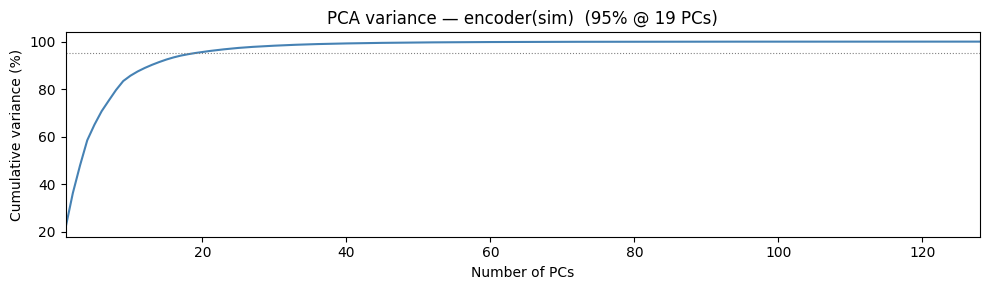

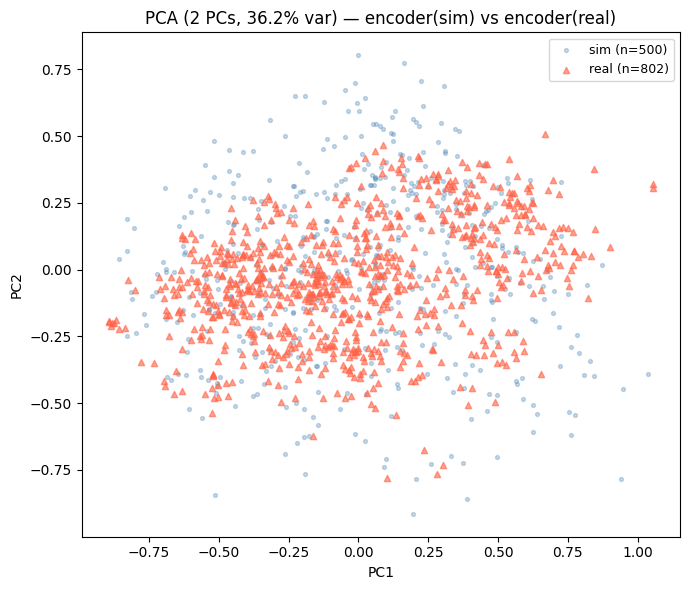

Running UMAP (19 PCs)...


/home/sa4604/cv-dann-sbi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


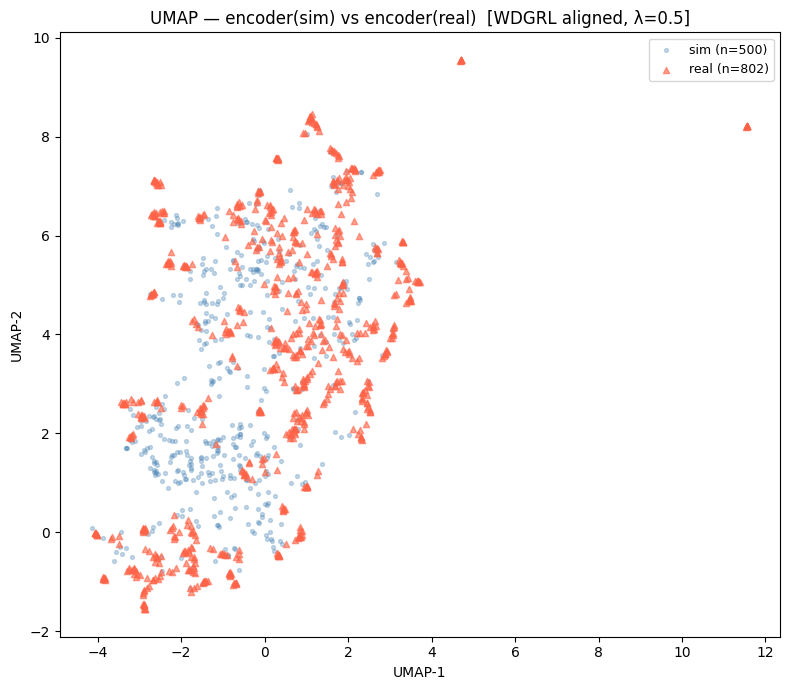

encoder(sim)  mean_std=0.073
encoder(real) mean_std=0.065  in sim bbox: 601/802 (74.9%)


In [6]:
from sklearn.decomposition import PCA
import umap
from torch.utils.data import DataLoader

ds_pca = ReducedCVDataset(str(SIM_ROOT / 'train'), manifest['index'][:N_SIM_PCA], stats)
_, x_sim_pca = next(iter(DataLoader(ds_pca, batch_size=N_SIM_PCA, num_workers=0)))
ds_pca.close()

with torch.no_grad():
    z_sim  = encoder(x_sim_pca.to(device)).cpu().numpy()
    z_real = torch.stack([
        encoder(pat['x_avg'].unsqueeze(0).to(device)).squeeze(0)
        for pat in patients
    ]).cpu().numpy()

pca_full = PCA().fit(z_sim)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_95     = int((cumvar < 0.95).sum()) + 1

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(1, len(cumvar)+1), cumvar * 100, linewidth=1.5, color='steelblue')
ax.axhline(95, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Number of PCs'); ax.set_ylabel('Cumulative variance (%)')
ax.set_title(f'PCA variance — encoder(sim)  (95% @ {n_95} PCs)')
ax.set_xlim(1, 128); plt.tight_layout(); plt.show()

pca2 = PCA(n_components=2).fit(z_sim)
zs2  = pca2.transform(z_sim)
zr2  = pca2.transform(z_real)
var  = pca2.explained_variance_ratio_.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(zs2[:, 0], zs2[:, 1], s=8,  alpha=0.3, color='steelblue', label=f'sim (n={N_SIM_PCA})')
ax.scatter(zr2[:, 0], zr2[:, 1], s=20, alpha=0.6, color='tomato',    label=f'real (n={len(patients)})', marker='^', zorder=5)
ax.set_title(f'PCA (2 PCs, {var:.1f}% var) — encoder(sim) vs encoder(real)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'Running UMAP ({n_95} PCs)...')
z_all  = pca_full.transform(np.concatenate([z_sim, z_real]))[:, :n_95]
z_umap = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.1).fit_transform(z_all)
ns     = len(z_sim)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(z_umap[:ns, 0], z_umap[:ns, 1], s=8,  alpha=0.3, color='steelblue', label=f'sim (n={ns})')
ax.scatter(z_umap[ns:, 0], z_umap[ns:, 1], s=20, alpha=0.6, color='tomato',    label=f'real (n={len(patients)})', marker='^', zorder=5)
ax.set_title(f'UMAP — encoder(sim) vs encoder(real)  [WDGRL aligned, λ=0.5]')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

in_bounds = np.all((z_real >= z_sim.min(axis=0)) & (z_real <= z_sim.max(axis=0)), axis=1)
print(f'encoder(sim)  mean_std={z_sim.std(axis=0).mean():.3f}')
print(f'encoder(real) mean_std={z_real.std(axis=0).mean():.3f}  in sim bbox: {in_bounds.sum()}/{len(z_real)} ({in_bounds.mean()*100:.1f}%)')

## UMAP colored by parameter values

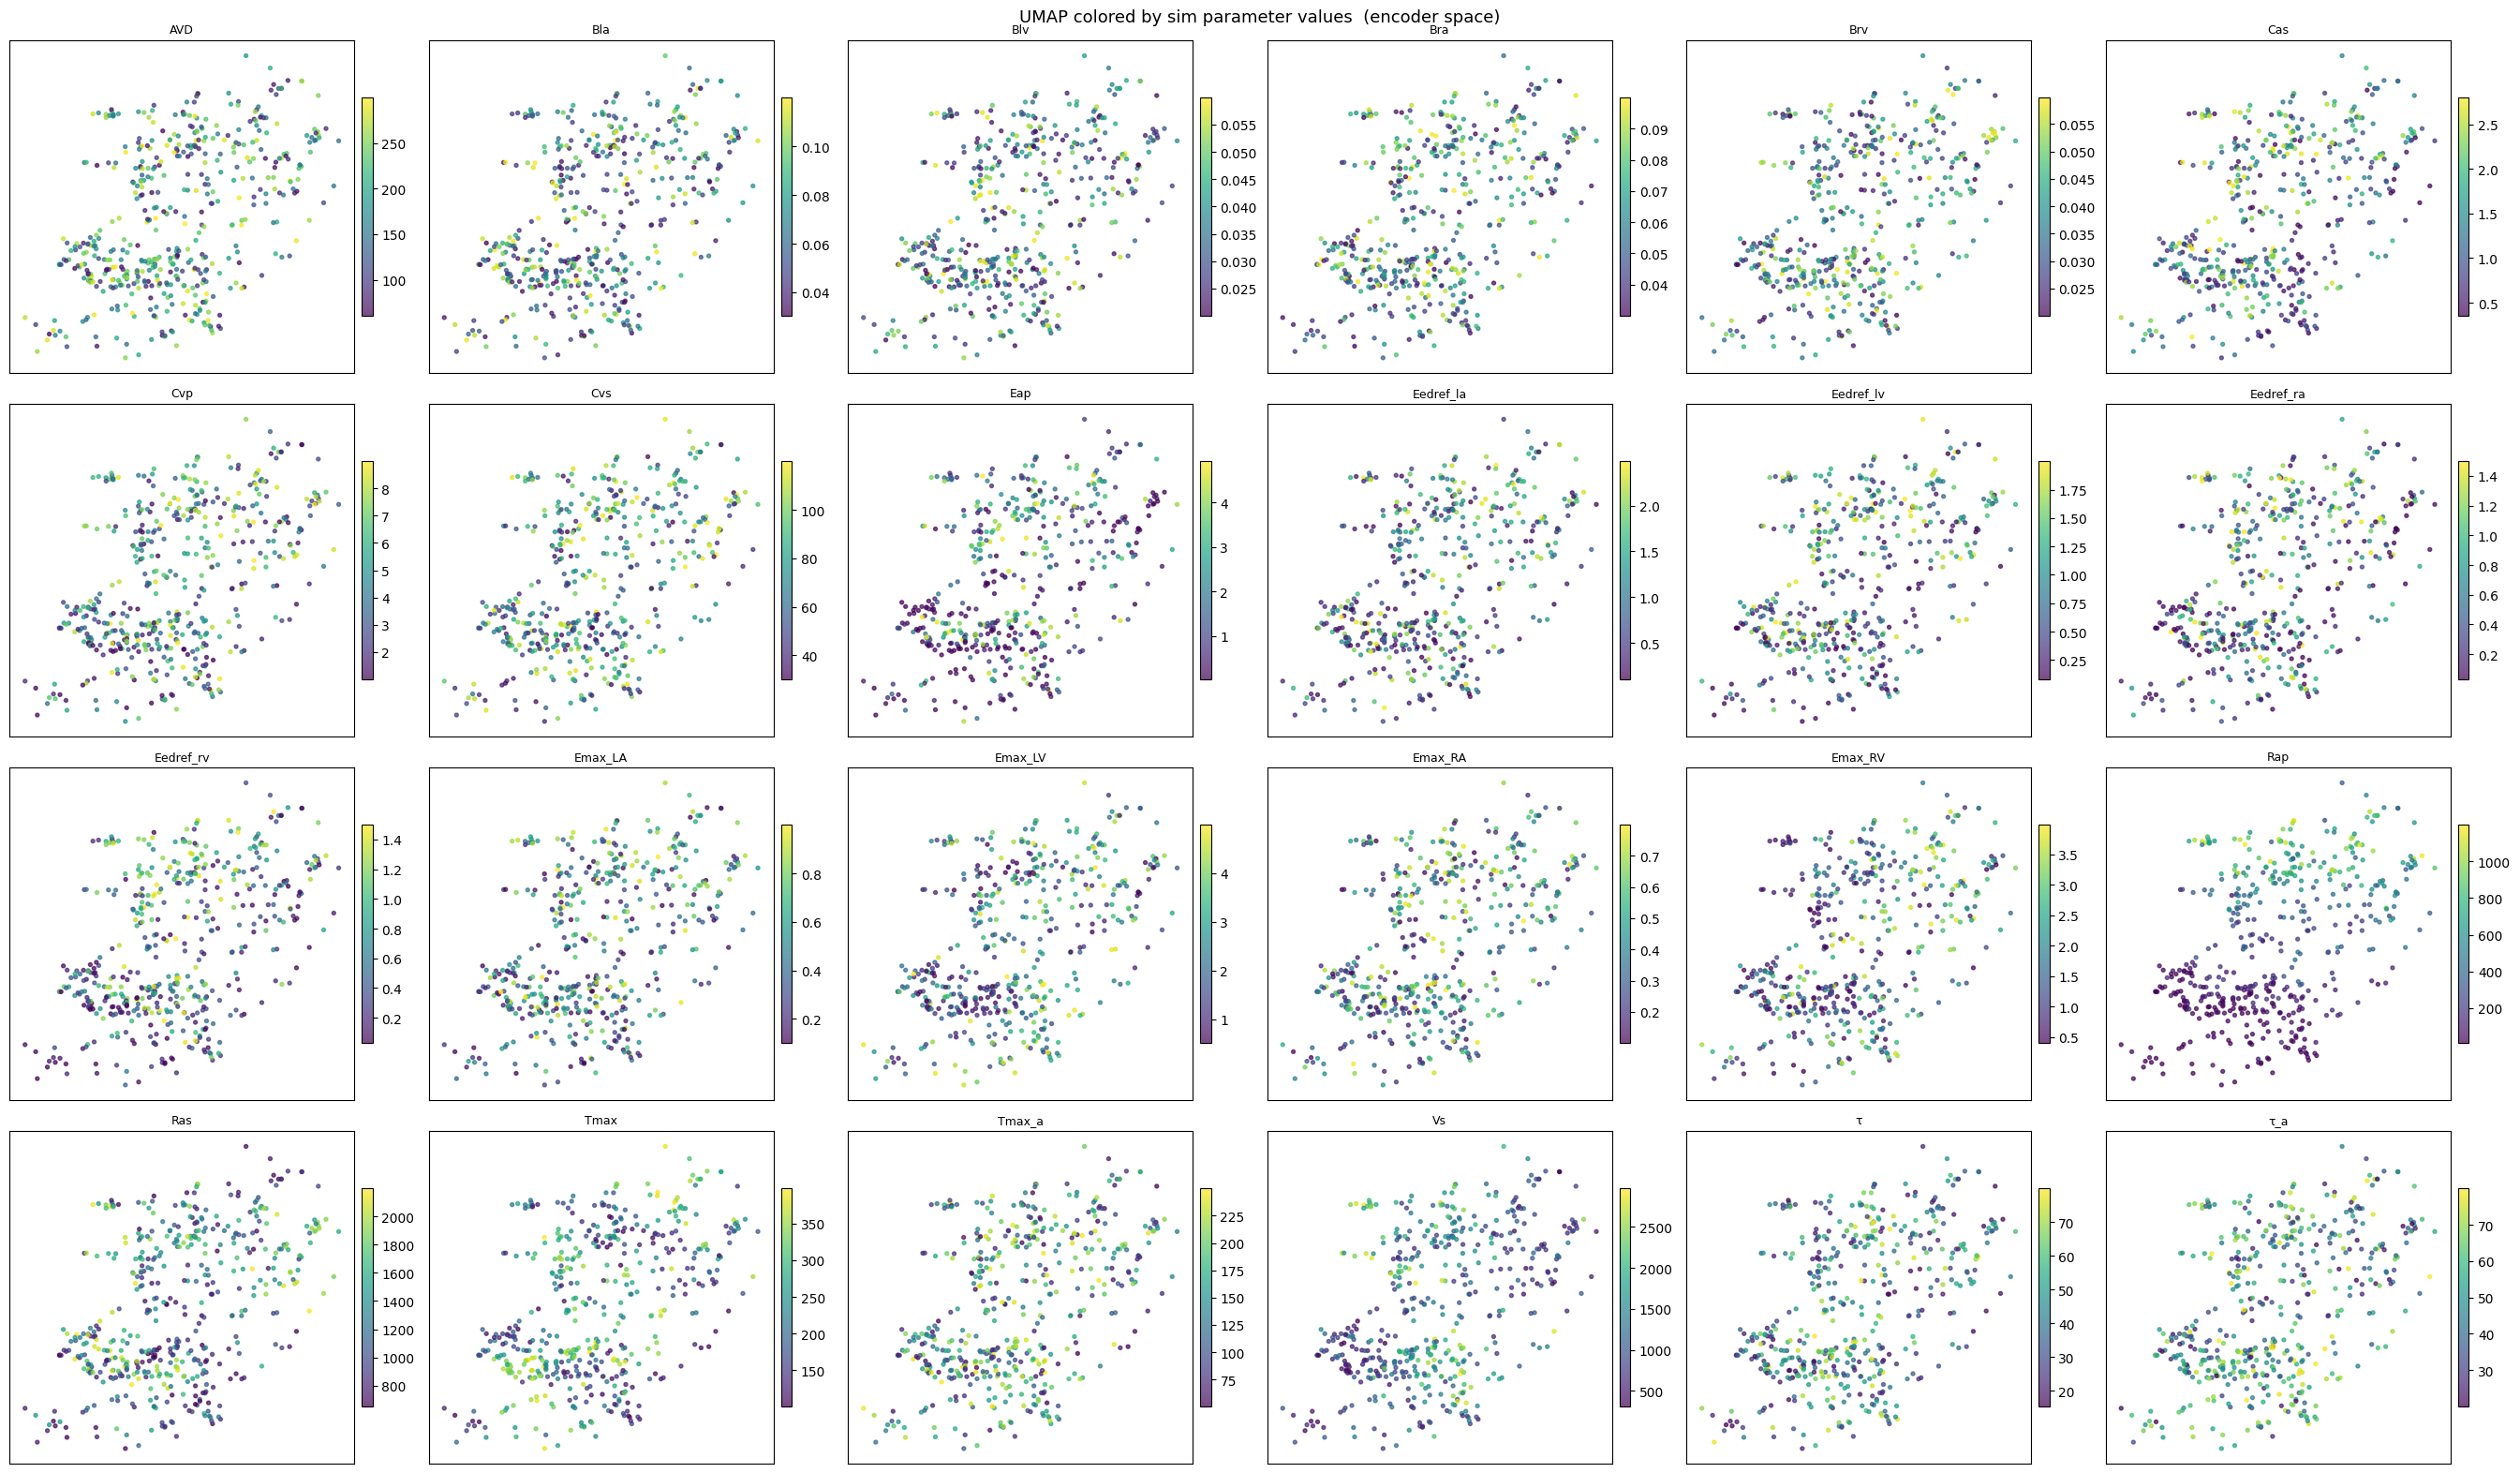

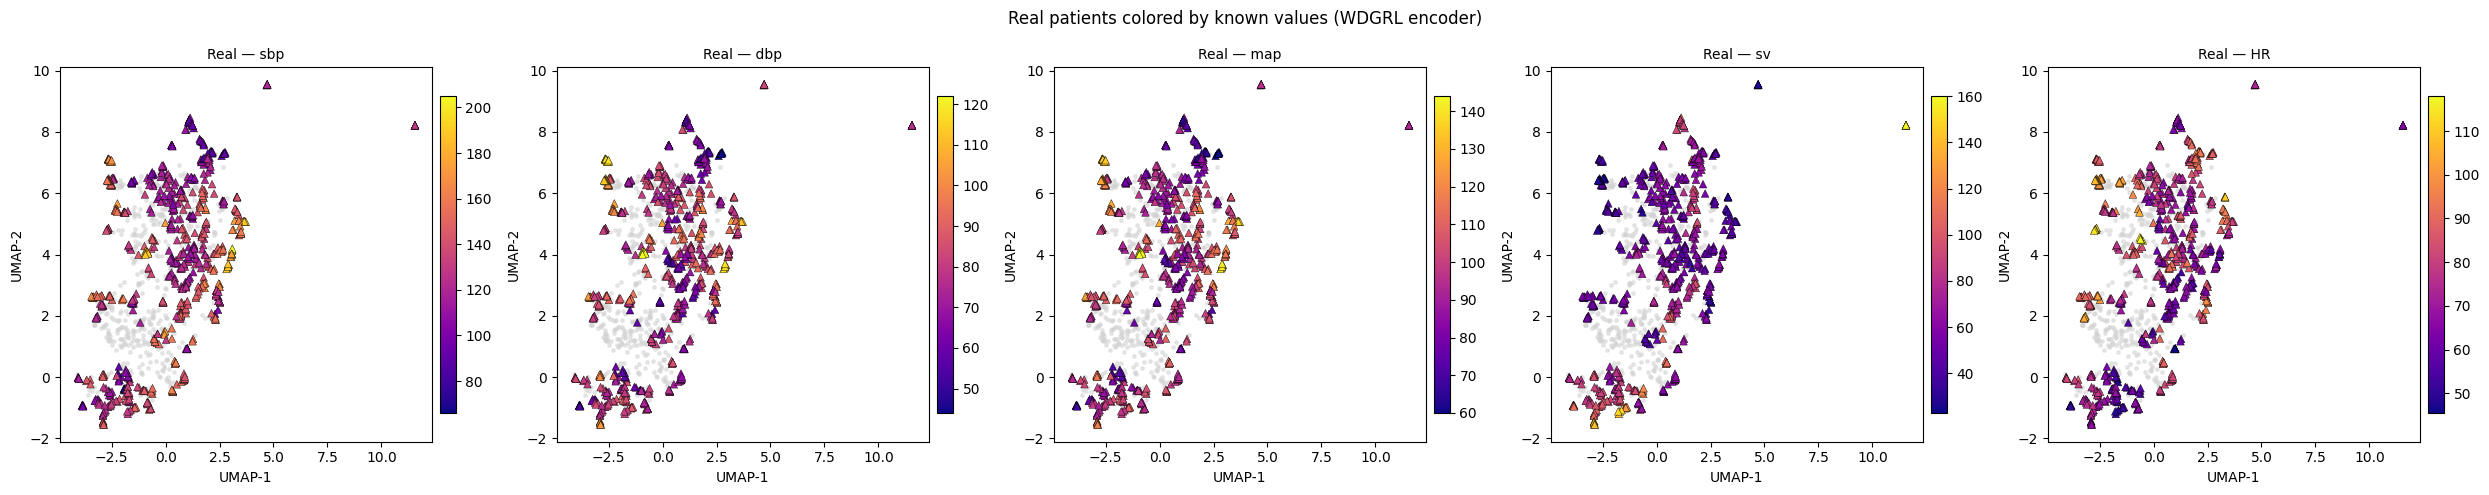

In [7]:
ds_theta = ReducedCVDataset(str(SIM_ROOT / 'train'), manifest['index'][:N_SIM_PCA], stats)
theta_sim_pca = torch.stack([ds_theta[i][0] for i in range(N_SIM_PCA)]).numpy()
ds_theta.close()

ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    sc = ax.scatter(z_umap[:ns, 0], z_umap[:ns, 1], c=theta_sim_pca[:, i],
                    cmap='viridis', s=8, alpha=0.7, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(name, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')
fig.suptitle('UMAP colored by sim parameter values  (encoder space)', fontsize=13)
plt.tight_layout(); plt.show()

hemo_keys = ['sbp', 'dbp', 'map', 'sv', 'HR']
hemo_keys = [k for k in hemo_keys if k in patients[0]['gt']]
fig, axes = plt.subplots(1, len(hemo_keys), figsize=(5 * len(hemo_keys), 5))
for ai, key in enumerate(hemo_keys):
    vals = np.array([pat['gt'].get(key, np.nan) for pat in patients])
    mask = ~np.isnan(vals)
    ax = axes[ai]
    ax.scatter(z_umap[:ns, 0], z_umap[:ns, 1], s=6, color='lightgrey', alpha=0.5, rasterized=True)
    sc = ax.scatter(z_umap[ns:][mask, 0], z_umap[ns:][mask, 1],
                    c=vals[mask], cmap='plasma', s=30, marker='^',
                    edgecolors='black', linewidths=0.3, zorder=5)
    plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(f'Real — {key}', fontsize=10)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
fig.suptitle('Real patients colored by known values (WDGRL encoder)', fontsize=12)
plt.tight_layout(); plt.show()

## Direct inference — flow on real patients

No nearest-neighbour proxy needed: `encoder(x_real)` is directly in sim latent space.
Full posterior samples retained for Rap and Ras for real patient calibration.

In [8]:
import time

cas_idx = PARAM_KEYS_INFER.index('Cas')
eap_idx = PARAM_KEYS_INFER.index('Eap')
rap_idx = PARAM_KEYS_INFER.index('Rap')
ras_idx = PARAM_KEYS_INFER.index('Ras')

print(f'Direct inference on {len(patients)} real patients (N={N_POSTERIOR_SAMPLES} samples each)...')

cas_d, eap_d, rap_d, ras_d, accept_rates, theta_means = [], [], [], [], [], []
rap_samples_all = []   # full posteriors for calibration
ras_samples_all = []
t0 = time.time()

for pi, pat in enumerate(patients):
    x = pat['x_avg'].unsqueeze(0).to(device)
    with torch.no_grad():
        z       = encoder(x)
        samples = flow_net.sample((N_POSTERIOR_SAMPLES,), condition=z).squeeze(1).cpu()  # (N, 24)
    in_prior = ((samples >= lo_t) & (samples <= hi_t)).all(dim=1)
    accept   = in_prior.float().mean().item()
    accept_rates.append(accept)
    s_ok  = samples[in_prior] if in_prior.any() else samples
    means = s_ok.mean(0).numpy()
    theta_means.append(means)
    cas_d.append(means[cas_idx]); eap_d.append(means[eap_idx])
    rap_d.append(means[rap_idx]); ras_d.append(means[ras_idx])
    rap_samples_all.append(samples[:, rap_idx].numpy())
    ras_samples_all.append(samples[:, ras_idx].numpy())
    if pi % 100 == 0 or pi < 3:
        print(f'  [{pi:3d}] accept={accept:.3f}  '
              f'Rap={rap_d[-1]:.2f} (GT={pat["gt"].get("PVR", float("nan")):.2f})  '
              f'Ras={ras_d[-1]:.2f} (GT={pat["gt"].get("SVR", float("nan")):.2f})  '
              f'({time.time()-t0:.0f}s)')

cas_d = np.array(cas_d); eap_d = np.array(eap_d)
rap_d = np.array(rap_d); ras_d = np.array(ras_d)
accept_rates    = np.array(accept_rates)
theta_means     = np.stack(theta_means)
rap_samples_all = np.stack(rap_samples_all)  # (802, N_posterior)
ras_samples_all = np.stack(ras_samples_all)
print(f'\nMean acceptance: {accept_rates.mean():.3f}  '
      f'({(accept_rates > 0).sum()}/{len(patients)} patients with nonzero acceptance)')

Direct inference on 802 real patients (N=1000 samples each)...
  [  0] accept=0.000  Rap=65.79 (GT=66.30)  Ras=957.05 (GT=967.00)  (0s)
  [  1] accept=0.001  Rap=64.81 (GT=67.00)  Ras=941.73 (GT=965.00)  (0s)
  [  2] accept=0.002  Rap=58.73 (GT=60.00)  Ras=966.59 (GT=984.00)  (0s)
  [100] accept=0.000  Rap=320.49 (GT=329.00)  Ras=621.80 (GT=648.00)  (4s)
  [200] accept=0.000  Rap=685.20 (GT=616.00)  Ras=1402.09 (GT=1410.00)  (7s)
  [300] accept=0.051  Rap=80.96 (GT=84.60)  Ras=1470.16 (GT=1480.00)  (11s)
  [400] accept=0.000  Rap=796.18 (GT=730.00)  Ras=1726.65 (GT=1720.00)  (15s)
  [500] accept=0.135  Rap=299.35 (GT=318.00)  Ras=1072.84 (GT=1110.00)  (18s)
  [600] accept=0.000  Rap=347.27 (GT=320.00)  Ras=757.82 (GT=765.00)  (22s)
  [700] accept=0.000  Rap=301.54 (GT=379.00)  Ras=1268.27 (GT=1360.00)  (26s)
  [800] accept=0.000  Rap=75.16 (GT=93.10)  Ras=868.24 (GT=979.00)  (29s)

Mean acceptance: 0.006  (78/802 patients with nonzero acceptance)


## Parameter scatter — posterior mean vs GT

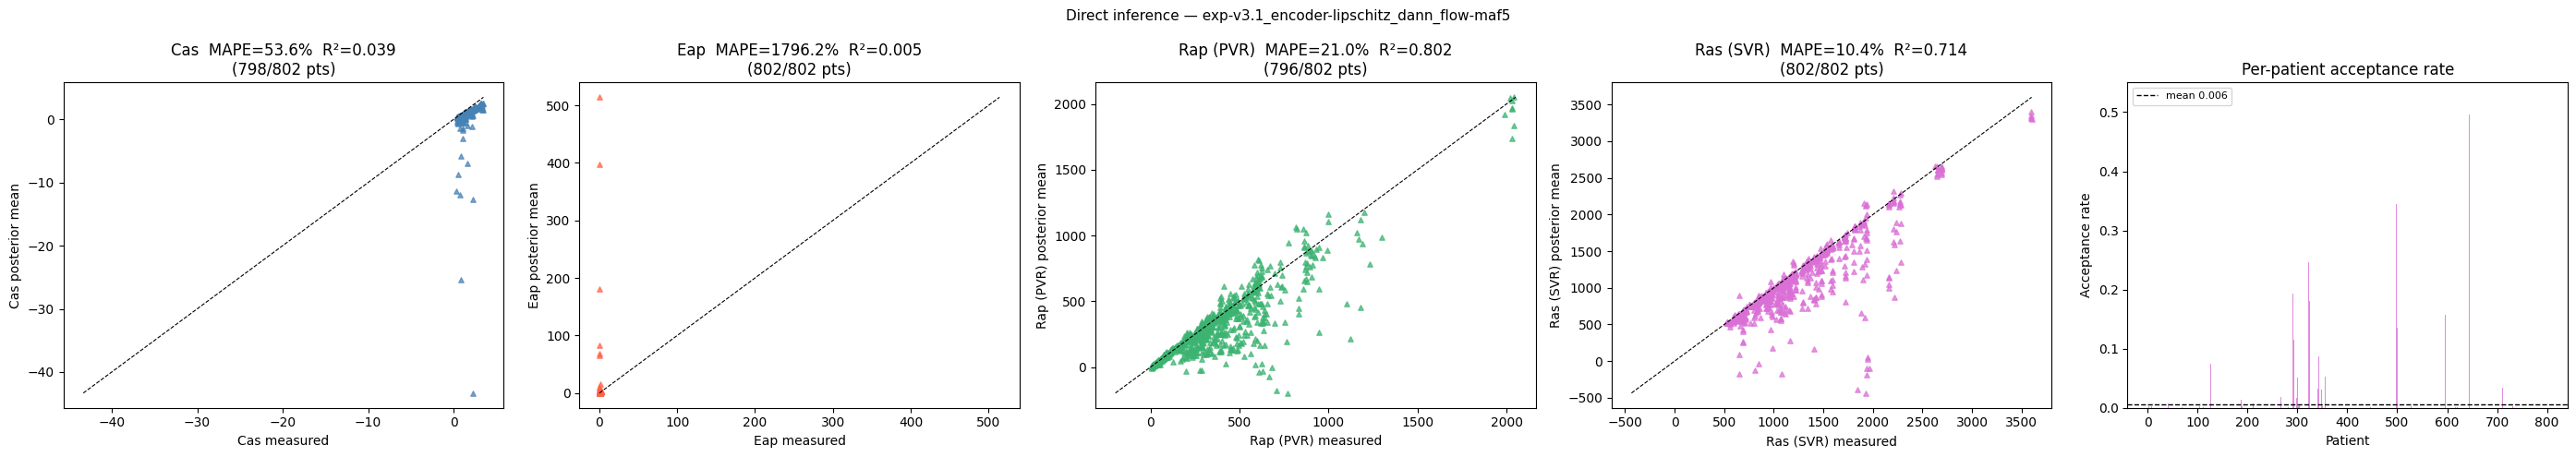


Parameter        MAPE      R²
------------------------------
Cas             53.6%   0.039
Eap           1796.2%   0.005
Rap(PVR)        21.0%   0.802
Ras(SVR)        10.4%   0.714


In [9]:
from scipy.stats import pearsonr

cas_gt = np.array([pat['gt'].get('Cas', np.nan) for pat in patients])
eap_gt = np.array([pat['gt'].get('Eap', np.nan) for pat in patients])
rap_gt = np.array([pat['gt'].get('PVR', np.nan) for pat in patients])
ras_gt = np.array([pat['gt'].get('SVR', np.nan) for pat in patients])

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
for ax, pred, gt, name, color in [
    (axes[0], cas_d, cas_gt, 'Cas',       'steelblue'),
    (axes[1], eap_d, eap_gt, 'Eap',       'tomato'),
    (axes[2], rap_d, rap_gt, 'Rap (PVR)', 'mediumseagreen'),
    (axes[3], ras_d, ras_gt, 'Ras (SVR)', 'orchid'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.any():
        lo = np.nanmin([gt[valid].min(), pred[valid].min()])
        hi = np.nanmax([gt[valid].max(), pred[valid].max()])
        ax.scatter(gt[valid], pred[valid], s=15, alpha=0.7, color=color, marker='^')
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        ax.set_title(f'{name}  MAPE={mape:.1f}%  R²={r2:.3f}\n({valid.sum()}/{len(patients)} pts)')
    else:
        ax.set_title(f'{name}  0 valid')
    ax.set_xlabel(f'{name} measured'); ax.set_ylabel(f'{name} posterior mean')

ax = axes[4]
ax.bar(range(len(patients)), accept_rates, color='orchid', alpha=0.8)
ax.axhline(accept_rates.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean {accept_rates.mean():.3f}')
ax.set_xlabel('Patient'); ax.set_ylabel('Acceptance rate')
ax.set_title('Per-patient acceptance rate'); ax.legend(fontsize=8)

fig.suptitle(f'Direct inference — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

print(f'\n{"Parameter":<12} {"MAPE":>8} {"R²":>7}')
print('-' * 30)
for pred, gt, name in [
    (cas_d, cas_gt, 'Cas'), (eap_d, eap_gt, 'Eap'),
    (rap_d, rap_gt, 'Rap(PVR)'), (ras_d, ras_gt, 'Ras(SVR)'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.sum() > 1:
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        print(f'{name:<12} {mape:>7.1f}%  {r2:>6.3f}')

## 1-NN flow proxy — unseen simulations as observation stand-ins

Instead of running the flow on `encoder(x_real)`, find the 1 nearest simulation in latent space
from a bank of **unseen sims** (indices beyond what training used), then run the flow conditioned
on that sim's encoding. The proxy sim is guaranteed to be in the flow's training distribution,
but the specific sim was never seen during training.

- Bank start index read from `run_info_v{VERSION}.json` → guarantees no overlap with training
- Bank encodings cached to `knn_proxy_bank.npz` for fast reloading
- 1-NN distance printed as a diagnostic: small = good latent alignment
- Flow posterior sampled on `encoder(x_proxy_sim)` — same 1000 samples as direct inference

In [ ]:
from sklearn.neighbors import NearestNeighbors

N_PROXY     = 50_000
PROXY_CACHE = RUN_DIR / 'knn_proxy_bank.npz'

# Read n_sims from run_info so proxy bank never overlaps training data
run_info_path = RUN_DIR / f'run_info_v{VERSION}.json'
with open(run_info_path) as f:
    run_info = json.load(f)
PROXY_START = run_info['data']['n_sims']
print(f'Training used {PROXY_START} sims → proxy bank starts at index {PROXY_START}')
print(f'Manifest has {len(manifest["index"])} total entries; proxy headroom: {len(manifest["index"]) - PROXY_START}')

if PROXY_CACHE.exists():
    loaded           = np.load(PROXY_CACHE)
    z_proxy_bank     = loaded['z_bank']
    theta_proxy_bank = loaded['theta_bank']
    print(f'Loaded proxy bank from cache: {z_proxy_bank.shape}')
else:
    proxy_entries = manifest['index'][PROXY_START : PROXY_START + N_PROXY]
    assert len(proxy_entries) >= N_PROXY, f'Not enough unseen sims: {len(proxy_entries)}'
    print(f'Encoding {N_PROXY} unseen sims (indices {PROXY_START}–{PROXY_START + N_PROXY})...')

    ds_proxy = ReducedCVDataset(str(SIM_ROOT / 'train'), proxy_entries, stats)
    theta_list, x_list = [], []
    for i in range(len(ds_proxy)):
        th, xb = ds_proxy[i]
        theta_list.append(th)
        x_list.append(xb)
    ds_proxy.close()
    theta_proxy_bank = torch.stack(theta_list).numpy()   # (N_PROXY, 24) raw sim units
    x_proxy          = torch.stack(x_list)               # (N_PROXY, 809)

    z_parts = []
    with torch.no_grad():
        for i in range(0, len(x_proxy), 256):
            z_parts.append(encoder(x_proxy[i:i+256].to(device)).cpu().numpy())
            if (i // 256) % 20 == 0:
                print(f'  {min(i+256, N_PROXY)}/{N_PROXY}', end='\r', flush=True)
    z_proxy_bank = np.concatenate(z_parts)   # (N_PROXY, 128)

    np.savez(PROXY_CACHE, z_bank=z_proxy_bank, theta_bank=theta_proxy_bank)
    print(f'\nSaved → {PROXY_CACHE}')

print(f'z_proxy_bank: {z_proxy_bank.shape}   theta_proxy_bank: {theta_proxy_bank.shape}')

In [ ]:
# Build 1-NN index and find nearest proxy sim for each real patient
knn_index = NearestNeighbors(n_neighbors=1, metric='euclidean', algorithm='auto', n_jobs=-1)
knn_index.fit(z_proxy_bank)
nn_dists_raw, nn_idx = knn_index.kneighbors(z_real)   # z_real from latent-space section: (802, 128)
nn_idx      = nn_idx[:, 0]                             # (802,)
nn_dists    = nn_dists_raw[:, 0]                       # (802,)
nn_z_proxy  = z_proxy_bank[nn_idx]                    # (802, 128) — proxy latents

print(f'1-NN distances (real → proxy sim):')
print(f'  mean={nn_dists.mean():.3f}  median={np.median(nn_dists):.3f}  '
      f'p95={np.percentile(nn_dists, 95):.3f}  max={nn_dists.max():.3f}')

# Compare to sim-to-sim distances as reference
sim_dists_ref = np.linalg.norm(z_proxy_bank[:500, None] - z_proxy_bank[None, :500], axis=2)
np.fill_diagonal(sim_dists_ref, np.inf)
nn_sim_dists = sim_dists_ref.min(axis=1)
print(f'1-NN distances (sim → sim, 500-sample ref):')
print(f'  mean={nn_sim_dists.mean():.3f}  median={np.median(nn_sim_dists):.3f}  '
      f'p95={np.percentile(nn_sim_dists, 95):.3f}')

# Run flow conditioned on proxy sim latent (not on x_real directly)
print(f'\nFlow inference on 1-NN proxy sims ({N_POSTERIOR_SAMPLES} samples/patient)...')
cas_nn, eap_nn, rap_nn, ras_nn = [], [], [], []
theta_means_nn = []
rap_nn_samples_all, ras_nn_samples_all = [], []
t0 = time.time()

for pi in range(len(patients)):
    z_pt = torch.from_numpy(nn_z_proxy[pi]).float().unsqueeze(0).to(device)  # (1, 128)
    with torch.no_grad():
        samples = flow_net.sample((N_POSTERIOR_SAMPLES,), condition=z_pt).squeeze(1).cpu()  # (N, 24)
    in_prior = ((samples >= lo_t) & (samples <= hi_t)).all(dim=1)
    s_ok  = samples[in_prior] if in_prior.any() else samples
    means = s_ok.mean(0).numpy()
    theta_means_nn.append(means)
    cas_nn.append(means[cas_idx]); eap_nn.append(means[eap_idx])
    rap_nn.append(means[rap_idx]); ras_nn.append(means[ras_idx])
    rap_nn_samples_all.append(samples[:, rap_idx].numpy())
    ras_nn_samples_all.append(samples[:, ras_idx].numpy())
    if pi % 100 == 0:
        print(f'  [{pi:3d}]  ({time.time()-t0:.0f}s)', end='\r', flush=True)

cas_nn = np.array(cas_nn); eap_nn = np.array(eap_nn)
rap_nn = np.array(rap_nn); ras_nn = np.array(ras_nn)
theta_means_nn     = np.stack(theta_means_nn)
rap_nn_samples_all = np.stack(rap_nn_samples_all)
ras_nn_samples_all = np.stack(ras_nn_samples_all)
print(f'\nDone.')

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, pred, gt, name, color in [
    (axes[0], cas_nn, cas_gt, 'Cas',       'steelblue'),
    (axes[1], eap_nn, eap_gt, 'Eap',       'tomato'),
    (axes[2], rap_nn, rap_gt, 'Rap (PVR)', 'mediumseagreen'),
    (axes[3], ras_nn, ras_gt, 'Ras (SVR)', 'orchid'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.any():
        lo = np.nanmin([gt[valid].min(), pred[valid].min()])
        hi = np.nanmax([gt[valid].max(), pred[valid].max()])
        ax.scatter(gt[valid], pred[valid], s=15, alpha=0.7, color=color, marker='^')
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        ax.set_title(f'{name}  MAPE={mape:.1f}%  R²={r2:.3f}\n({valid.sum()}/{len(patients)} pts)')
    else:
        ax.set_title(f'{name}  0 valid')
    ax.set_xlabel(f'{name} measured'); ax.set_ylabel(f'{name} 1-NN proxy mean')

fig.suptitle(f'1-NN flow proxy inference  (proxy bank N={N_PROXY}) — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

# Side-by-side comparison table: direct vs 1-NN proxy
print(f'\n{"Parameter":<12} {"Direct MAPE":>12} {"Direct R²":>10} {"1-NN MAPE":>11} {"1-NN R²":>9}')
print('-' * 58)
for pred_d, pred_nn, gt, name in [
    (cas_d, cas_nn, cas_gt, 'Cas'),
    (eap_d, eap_nn, eap_gt, 'Eap'),
    (rap_d, rap_nn, rap_gt, 'Rap(PVR)'),
    (ras_d, ras_nn, ras_gt, 'Ras(SVR)'),
]:
    valid_d  = ~np.isnan(pred_d)  & ~np.isnan(gt) & (gt >= 0)
    valid_nn = ~np.isnan(pred_nn) & ~np.isnan(gt) & (gt >= 0)
    md = np.nanmean(np.abs(pred_d[valid_d]   - gt[valid_d])   / (np.abs(gt[valid_d])   + 1e-9)) * 100
    rd = pearsonr(gt[valid_d],  pred_d[valid_d])[0]  ** 2
    mn = np.nanmean(np.abs(pred_nn[valid_nn] - gt[valid_nn]) / (np.abs(gt[valid_nn]) + 1e-9)) * 100
    rn = pearsonr(gt[valid_nn], pred_nn[valid_nn])[0] ** 2
    print(f'{name:<12} {md:>11.1f}%  {rd:>9.3f}  {mn:>10.1f}%  {rn:>8.3f}')

## Real patient calibration — Rap (PVR) and Ras (SVR)

For each patient, check whether the measured PVR/SVR falls within the posterior credible interval.
Unlike sim calibration (where true theta is exact), real GT has measurement noise — so expect
slightly looser calibration even from a perfect model.

In [ ]:
alphas = np.linspace(0.05, 0.95, 19)

rap_valid = ~np.isnan(rap_gt) & (rap_gt >= 0)
ras_valid = ~np.isnan(ras_gt) & (ras_gt >= 0)

def coverage_curve(samples_all, gt, valid, alphas):
    cov = np.zeros(len(alphas))
    for ai, alpha in enumerate(alphas):
        lo_q, hi_q = (1 - alpha) / 2 * 100, (100 - (1 - alpha) / 2 * 100)
        lo = np.percentile(samples_all, lo_q, axis=1)
        hi = np.percentile(samples_all, hi_q, axis=1)
        cov[ai] = ((gt[valid] >= lo[valid]) & (gt[valid] <= hi[valid])).mean()
    return cov

rap_cov    = coverage_curve(rap_samples_all,    rap_gt, rap_valid, alphas)
ras_cov    = coverage_curve(ras_samples_all,    ras_gt, ras_valid, alphas)
rap_cov_nn = coverage_curve(rap_nn_samples_all, rap_gt, rap_valid, alphas)
ras_cov_nn = coverage_curve(ras_nn_samples_all, ras_gt, ras_valid, alphas)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cov, cov_nn, name, color, n_valid in [
    (axes[0], rap_cov, rap_cov_nn, 'Rap (PVR)', 'mediumseagreen', rap_valid.sum()),
    (axes[1], ras_cov, ras_cov_nn, 'Ras (SVR)', 'orchid',         ras_valid.sum()),
]:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='ideal')
    ax.plot(alphas, cov,    color=color, linewidth=2, marker='o', markersize=4, label='direct flow')
    ax.plot(alphas, cov_nn, color=color, linewidth=2, marker='s', markersize=4,
            linestyle='--', alpha=0.75, label='1-NN proxy')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Nominal coverage'); ax.set_ylabel('Empirical coverage')
    ax.set_title(f'{name} — real patient calibration (n={n_valid})')
    ax.legend(fontsize=9)

fig.suptitle(f'Real patient credible interval calibration — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

idx_90 = alphas.searchsorted(0.9)
print(f'Coverage at 90% CI (ideal=0.90):')
print(f'{"":20} {"direct":>8} {"1-NN proxy":>12}')
print(f'  Rap (PVR)  (n={rap_valid.sum()})  {rap_cov[idx_90]:>8.3f} {rap_cov_nn[idx_90]:>12.3f}')
print(f'  Ras (SVR)  (n={ras_valid.sum()})  {ras_cov[idx_90]:>8.3f} {ras_cov_nn[idx_90]:>12.3f}')

## Parameter correlation heatmap

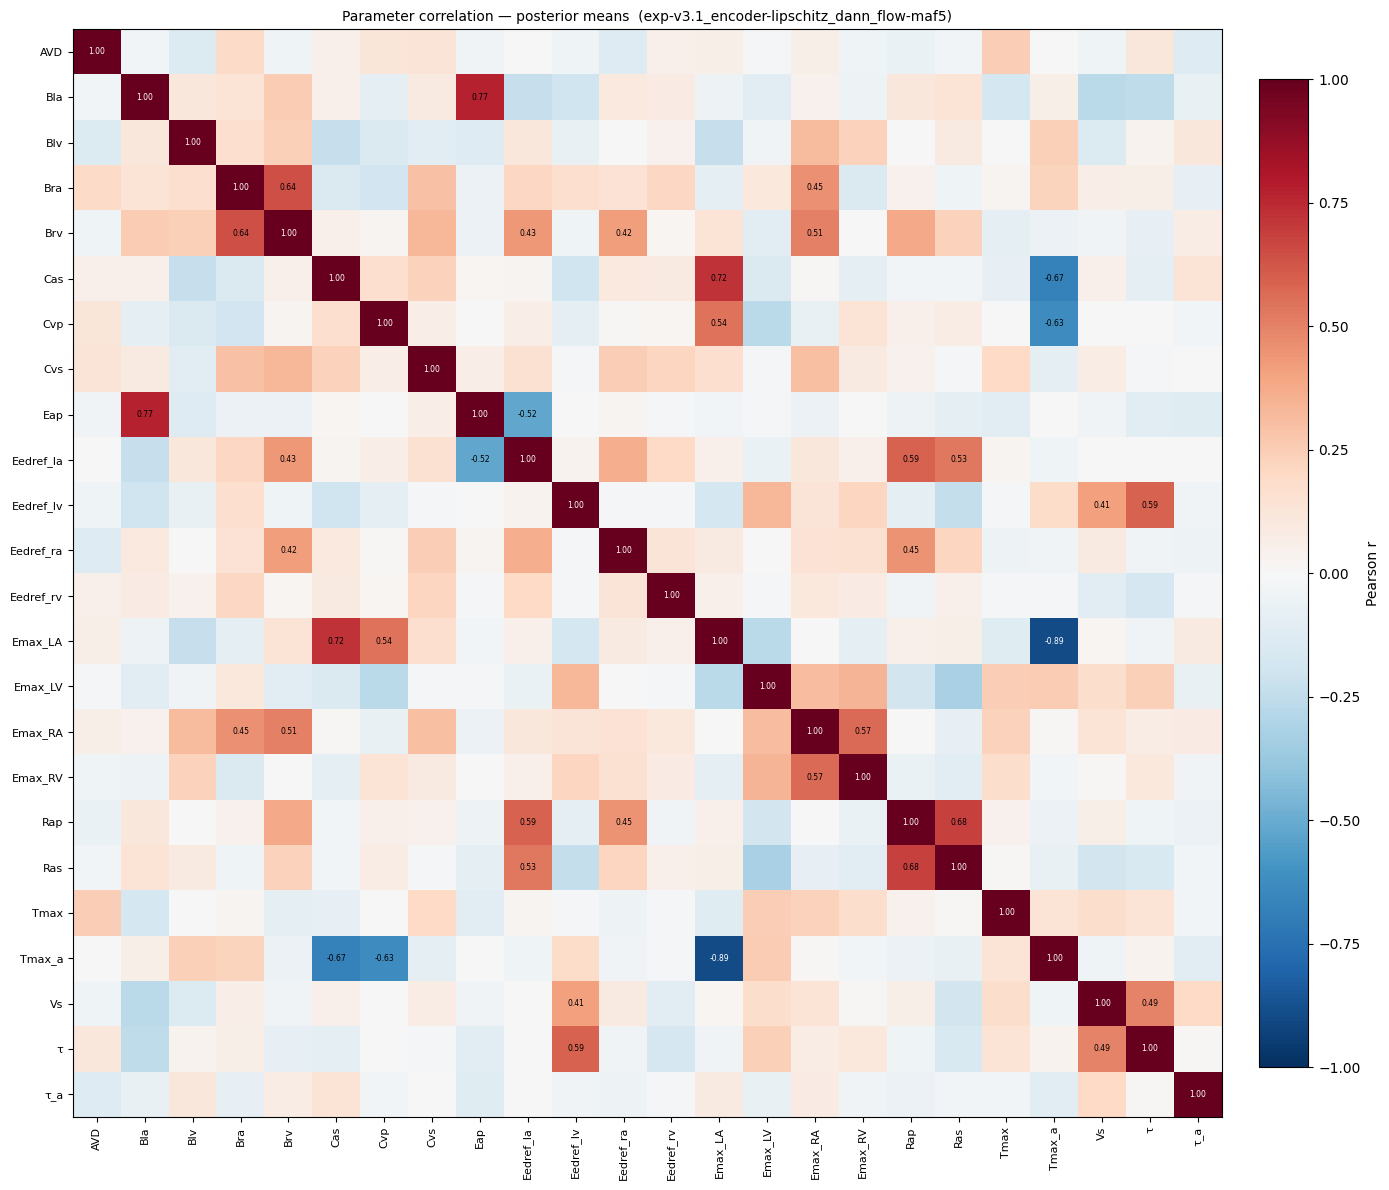

In [11]:
corr = np.corrcoef(theta_means.T)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label='Pearson r')
ticks = range(len(PARAM_KEYS_INFER))
ax.set_xticks(ticks); ax.set_xticklabels(PARAM_KEYS_INFER, rotation=90, fontsize=8)
ax.set_yticks(ticks); ax.set_yticklabels(PARAM_KEYS_INFER, fontsize=8)
for i in range(len(PARAM_KEYS_INFER)):
    for j in range(len(PARAM_KEYS_INFER)):
        val = corr[i, j]
        if abs(val) > 0.4:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=5.5, color='black' if abs(val) < 0.8 else 'white')
ax.set_title(f'Parameter correlation — posterior means  ({RUN})', fontsize=10)
plt.tight_layout(); plt.show()

## PAH vs controls — key parameter estimates

Comparing posterior means for 4 parameters across PAH (n=629) and control (n=173) patients.

- **Rap** (PVR, R²=1.000 on sims): direct disease marker — should be clearly elevated in PAH
- **Ras** (SVR, R²=0.998 on sims): elevated in v3 PAH cohort (genuine, not model artefact)
- **Emax_RV** (R²=0.974 on sims): RV contractile adaptation — higher in compensated PAH
- **Tmax** (R²=0.988 on sims): RV contraction timing — prolonged in PAH

Rap (PVR):  controls=47.0136±32.0898  PAH=358.5880±288.7994  MWU p=0.0000  (Higher in PAH (disease definition))
Ras (SVR):  controls=918.8810±284.2071  PAH=1137.1515±526.5173  MWU p=0.0000  (Elevated in PAH cohort (genuine, not artefact))
Emax_RV:  controls=0.3844±0.2221  PAH=0.7735±3.7865  MWU p=0.9693  (Higher in compensated PAH (RV adaptation))
Tmax:  controls=268.2891±35.5673  PAH=279.7904±33.5028  MWU p=0.0000  (RV contraction timing — prolonged in PAH)


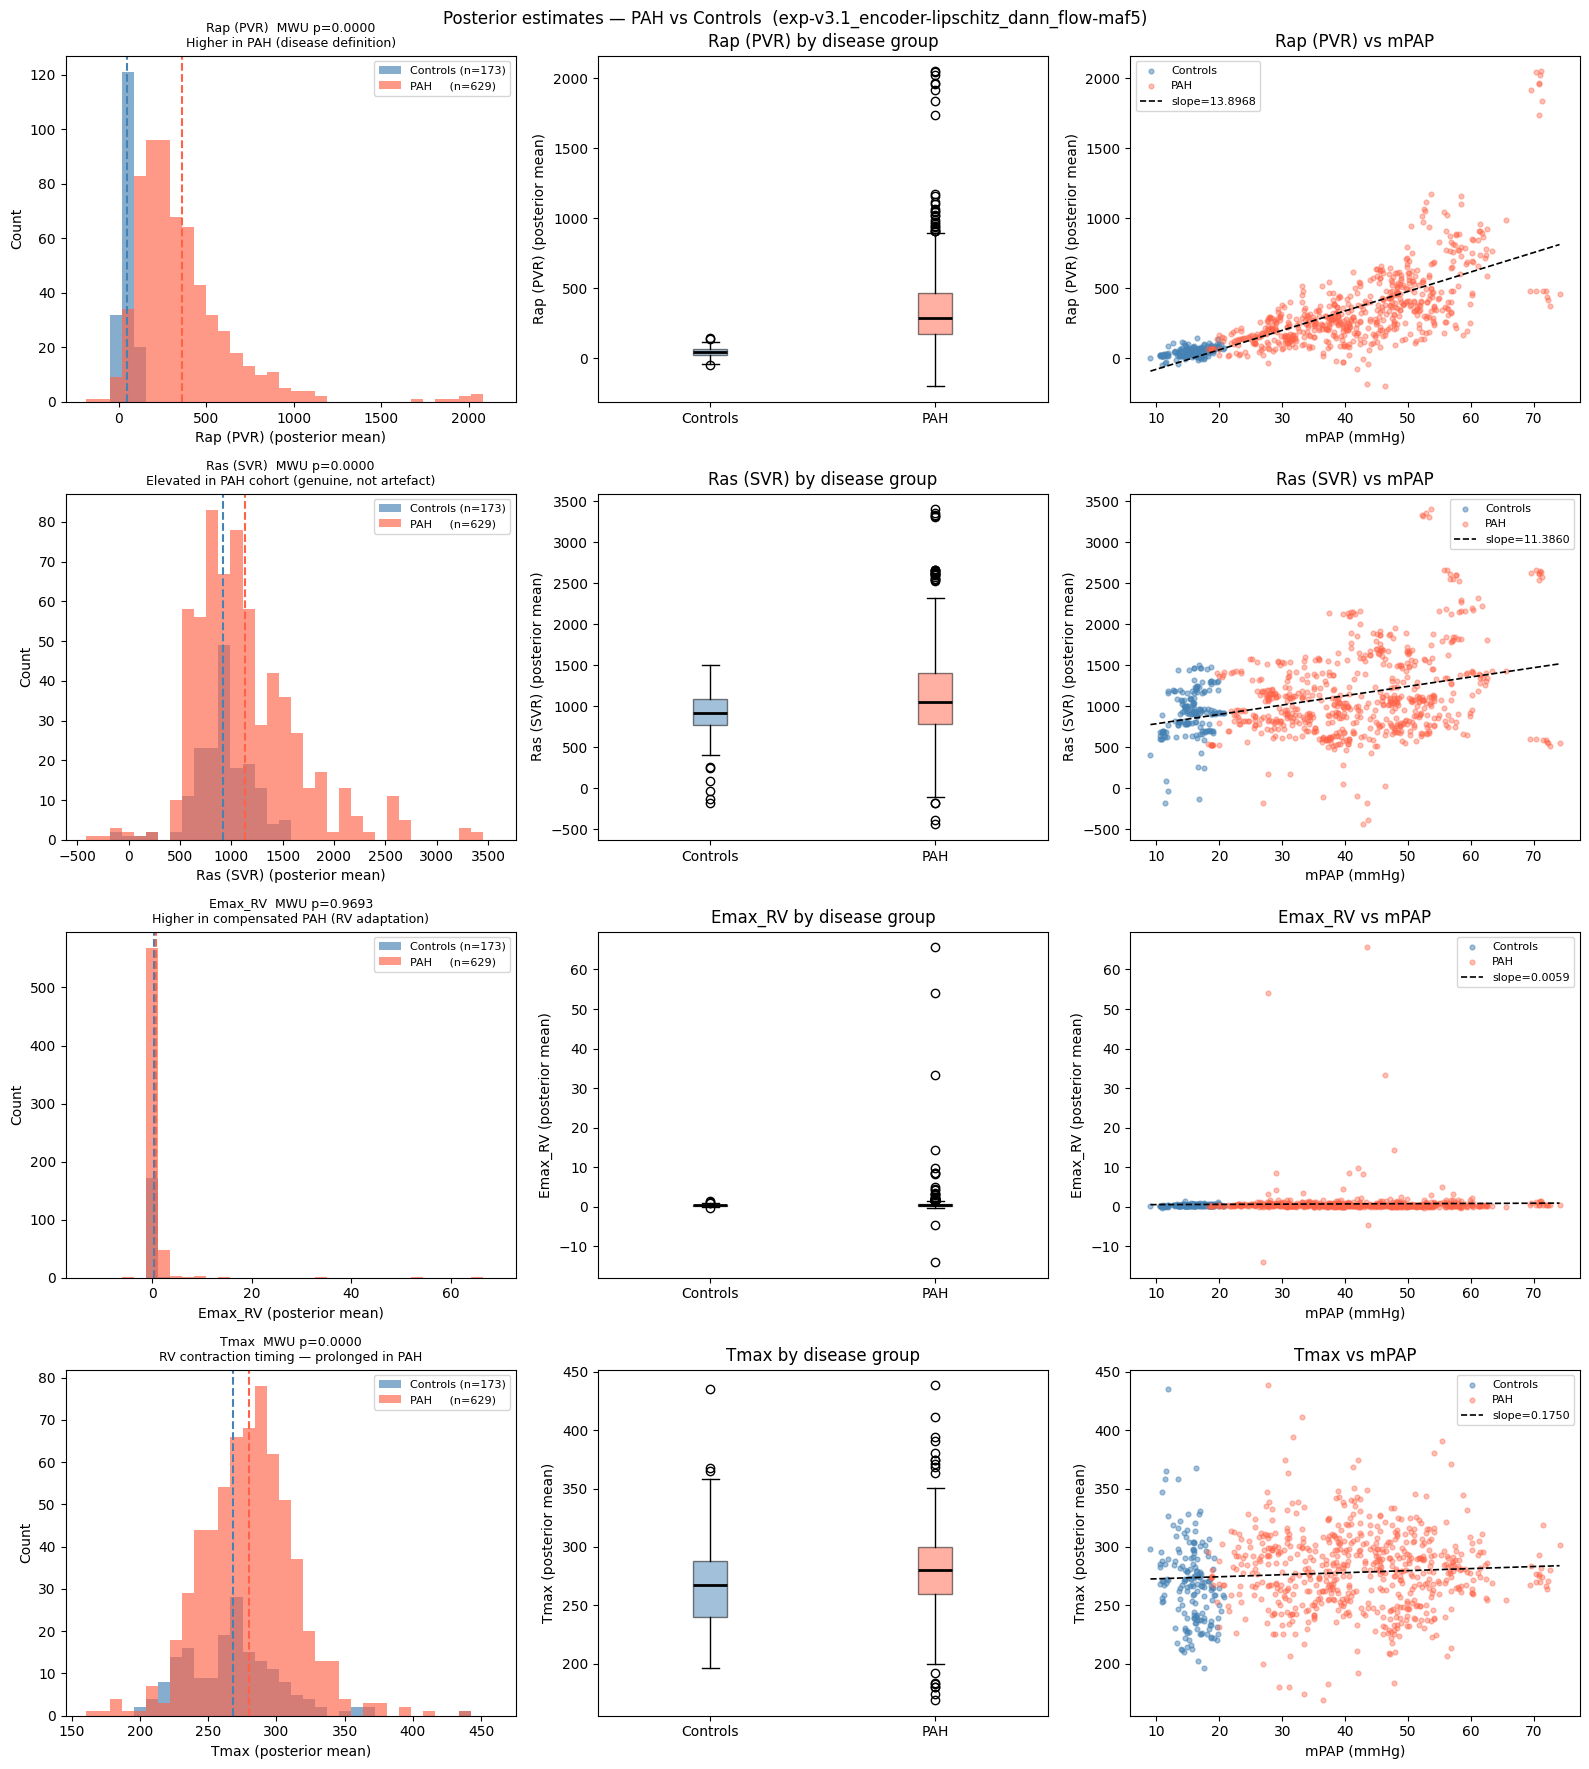

In [12]:
from scipy.stats import mannwhitneyu, ttest_ind

cohorts   = np.array([pat['gt'].get('cohort', '') for pat in patients])
pah_mask  = cohorts == 'pah'
ctrl_mask = cohorts == 'controls'
mpap_vals = np.array([pat['gt'].get('mpap', np.nan) for pat in patients])

PARAMS_TO_COMPARE = [
    ('Rap',     'Rap (PVR)',    'mediumseagreen', 'Higher in PAH (disease definition)'),
    ('Ras',     'Ras (SVR)',    'steelblue',      'Elevated in PAH cohort (genuine, not artefact)'),
    ('Emax_RV', 'Emax_RV',     'tomato',         'Higher in compensated PAH (RV adaptation)'),
    ('Tmax',    'Tmax',        'orchid',          'RV contraction timing — prolonged in PAH'),
]

fig, axes = plt.subplots(len(PARAMS_TO_COMPARE), 3,
                         figsize=(16, 4.5 * len(PARAMS_TO_COMPARE)))

for row, (pname, label, color, note) in enumerate(PARAMS_TO_COMPARE):
    pidx = PARAM_KEYS_INFER.index(pname)
    vals = theta_means[:, pidx]

    pah_v  = vals[pah_mask]
    ctrl_v = vals[ctrl_mask]
    p_mwu  = mannwhitneyu(pah_v, ctrl_v, alternative='two-sided').pvalue

    print(f'{label}:  controls={ctrl_v.mean():.4f}±{ctrl_v.std():.4f}  '
          f'PAH={pah_v.mean():.4f}±{pah_v.std():.4f}  '
          f'MWU p={p_mwu:.4f}  ({note})')

    ax = axes[row, 0]
    bins = np.linspace(vals.min() * 0.95, vals.max() * 1.05, 35)
    ax.hist(ctrl_v, bins=bins, color='steelblue', alpha=0.65, label=f'Controls (n={ctrl_mask.sum()})')
    ax.hist(pah_v,  bins=bins, color='tomato',    alpha=0.65, label=f'PAH     (n={pah_mask.sum()})')
    ax.axvline(ctrl_v.mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(pah_v.mean(),  color='tomato',    linestyle='--', linewidth=1.5)
    ax.set_xlabel(f'{label} (posterior mean)'); ax.set_ylabel('Count')
    ax.set_title(f'{label}  MWU p={p_mwu:.4f}\n{note}', fontsize=9); ax.legend(fontsize=8)

    ax = axes[row, 1]
    bp = ax.boxplot([ctrl_v, pah_v], tick_labels=['Controls', 'PAH'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('tomato');    bp['boxes'][1].set_alpha(0.5)
    for med in bp['medians']: med.set(color='black', linewidth=2)
    ax.set_ylabel(f'{label} (posterior mean)'); ax.set_title(f'{label} by disease group')

    ax = axes[row, 2]
    valid_mpap = ~np.isnan(mpap_vals)
    ax.scatter(mpap_vals[ctrl_mask & valid_mpap], vals[ctrl_mask & valid_mpap],
               s=12, alpha=0.5, color='steelblue', label='Controls')
    ax.scatter(mpap_vals[pah_mask  & valid_mpap], vals[pah_mask  & valid_mpap],
               s=12, alpha=0.4, color='tomato',    label='PAH')
    m, b = np.polyfit(mpap_vals[valid_mpap], vals[valid_mpap], 1)
    x_line = np.linspace(np.nanmin(mpap_vals), np.nanmax(mpap_vals), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.2, label=f'slope={m:.4f}')
    ax.set_xlabel('mPAP (mmHg)'); ax.set_ylabel(f'{label} (posterior mean)')
    ax.set_title(f'{label} vs mPAP'); ax.legend(fontsize=8)

fig.suptitle(f'Posterior estimates — PAH vs Controls  ({RUN})', fontsize=12)
plt.tight_layout(); plt.show()

## PAH vs controls — 1-NN proxy posterior

In [ ]:
fig, axes = plt.subplots(len(PARAMS_TO_COMPARE), 3,
                         figsize=(16, 4.5 * len(PARAMS_TO_COMPARE)))

for row, (pname, label, color, note) in enumerate(PARAMS_TO_COMPARE):
    pidx   = PARAM_KEYS_INFER.index(pname)
    vals   = theta_means_nn[:, pidx]
    pah_v  = vals[pah_mask]
    ctrl_v = vals[ctrl_mask]
    p_mwu  = mannwhitneyu(pah_v, ctrl_v, alternative='two-sided').pvalue

    print(f'{label}:  controls={ctrl_v.mean():.4f}±{ctrl_v.std():.4f}  '
          f'PAH={pah_v.mean():.4f}±{pah_v.std():.4f}  MWU p={p_mwu:.4f}  ({note})')

    ax = axes[row, 0]
    bins = np.linspace(vals.min() * 0.95, vals.max() * 1.05, 35)
    ax.hist(ctrl_v, bins=bins, color='steelblue', alpha=0.65, label=f'Controls (n={ctrl_mask.sum()})')
    ax.hist(pah_v,  bins=bins, color='tomato',    alpha=0.65, label=f'PAH     (n={pah_mask.sum()})')
    ax.axvline(ctrl_v.mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(pah_v.mean(),  color='tomato',    linestyle='--', linewidth=1.5)
    ax.set_xlabel(f'{label} (1-NN proxy mean)'); ax.set_ylabel('Count')
    ax.set_title(f'{label}  MWU p={p_mwu:.4f}\n{note}', fontsize=9); ax.legend(fontsize=8)

    ax = axes[row, 1]
    bp = ax.boxplot([ctrl_v, pah_v], tick_labels=['Controls', 'PAH'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('tomato');    bp['boxes'][1].set_alpha(0.5)
    for med in bp['medians']: med.set(color='black', linewidth=2)
    ax.set_ylabel(f'{label} (1-NN proxy mean)'); ax.set_title(f'{label} by disease group')

    ax = axes[row, 2]
    valid_mpap = ~np.isnan(mpap_vals)
    ax.scatter(mpap_vals[ctrl_mask & valid_mpap], vals[ctrl_mask & valid_mpap],
               s=12, alpha=0.5, color='steelblue', label='Controls')
    ax.scatter(mpap_vals[pah_mask  & valid_mpap], vals[pah_mask  & valid_mpap],
               s=12, alpha=0.4, color='tomato',    label='PAH')
    m, b = np.polyfit(mpap_vals[valid_mpap], vals[valid_mpap], 1)
    x_line = np.linspace(np.nanmin(mpap_vals), np.nanmax(mpap_vals), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.2, label=f'slope={m:.4f}')
    ax.set_xlabel('mPAP (mmHg)'); ax.set_ylabel(f'{label} (1-NN proxy mean)')
    ax.set_title(f'{label} vs mPAP'); ax.legend(fontsize=8)

fig.suptitle(f'1-NN proxy posterior — PAH vs Controls  ({RUN})', fontsize=12)
plt.tight_layout(); plt.show()

## Sim evaluation — posterior scatter, error metrics, and credible interval coverage

Uses held-out test sims (true theta known). For each sim: `encoder(x) → z → flow.sample(1000)`.
Posterior mean vs true theta gives MAPE/MAE/R²; posterior quantiles give coverage calibration.

In [13]:
N_SIM_EVAL = 1000
ncols, nrows = 6, 4

manifest_test = load_manifest(SIM_ROOT / 'manifest_test.json')
ds_test = ReducedCVDataset(str(SIM_ROOT / 'test'), manifest_test['index'][:N_SIM_EVAL], stats)
theta_test, x_test = zip(*[ds_test[i] for i in range(len(ds_test))])
ds_test.close()
theta_test = torch.stack(list(theta_test))
x_test     = torch.stack(list(x_test))
print(f'Test sims: {tuple(theta_test.shape)}  obs: {tuple(x_test.shape)}')

print(f'Running inference on {N_SIM_EVAL} test sims...')
sim_samples = []
t0 = time.time()
with torch.no_grad():
    for i in range(0, len(x_test), 64):
        x_b = x_test[i:i+64].to(device)
        z_b = encoder(x_b)
        for j in range(len(x_b)):
            s = flow_net.sample(
                (N_POSTERIOR_SAMPLES,), condition=z_b[j:j+1]
            ).squeeze(1).cpu()
            sim_samples.append(s)
        if (i // 64) % 5 == 0:
            print(f'  {i+len(x_b)}/{N_SIM_EVAL}  ({time.time()-t0:.0f}s)', end='\r', flush=True)

sim_samples = torch.stack(sim_samples)
sim_means   = sim_samples.mean(dim=1).numpy()
theta_np    = theta_test.numpy()
print(f'\nDone. sim_samples: {tuple(sim_samples.shape)}')

Test sims: (1000, 24)  obs: (1000, 809)
Running inference on 1000 test sims...
  1000/1000  (33s)
Done. sim_samples: (1000, 1000, 24)


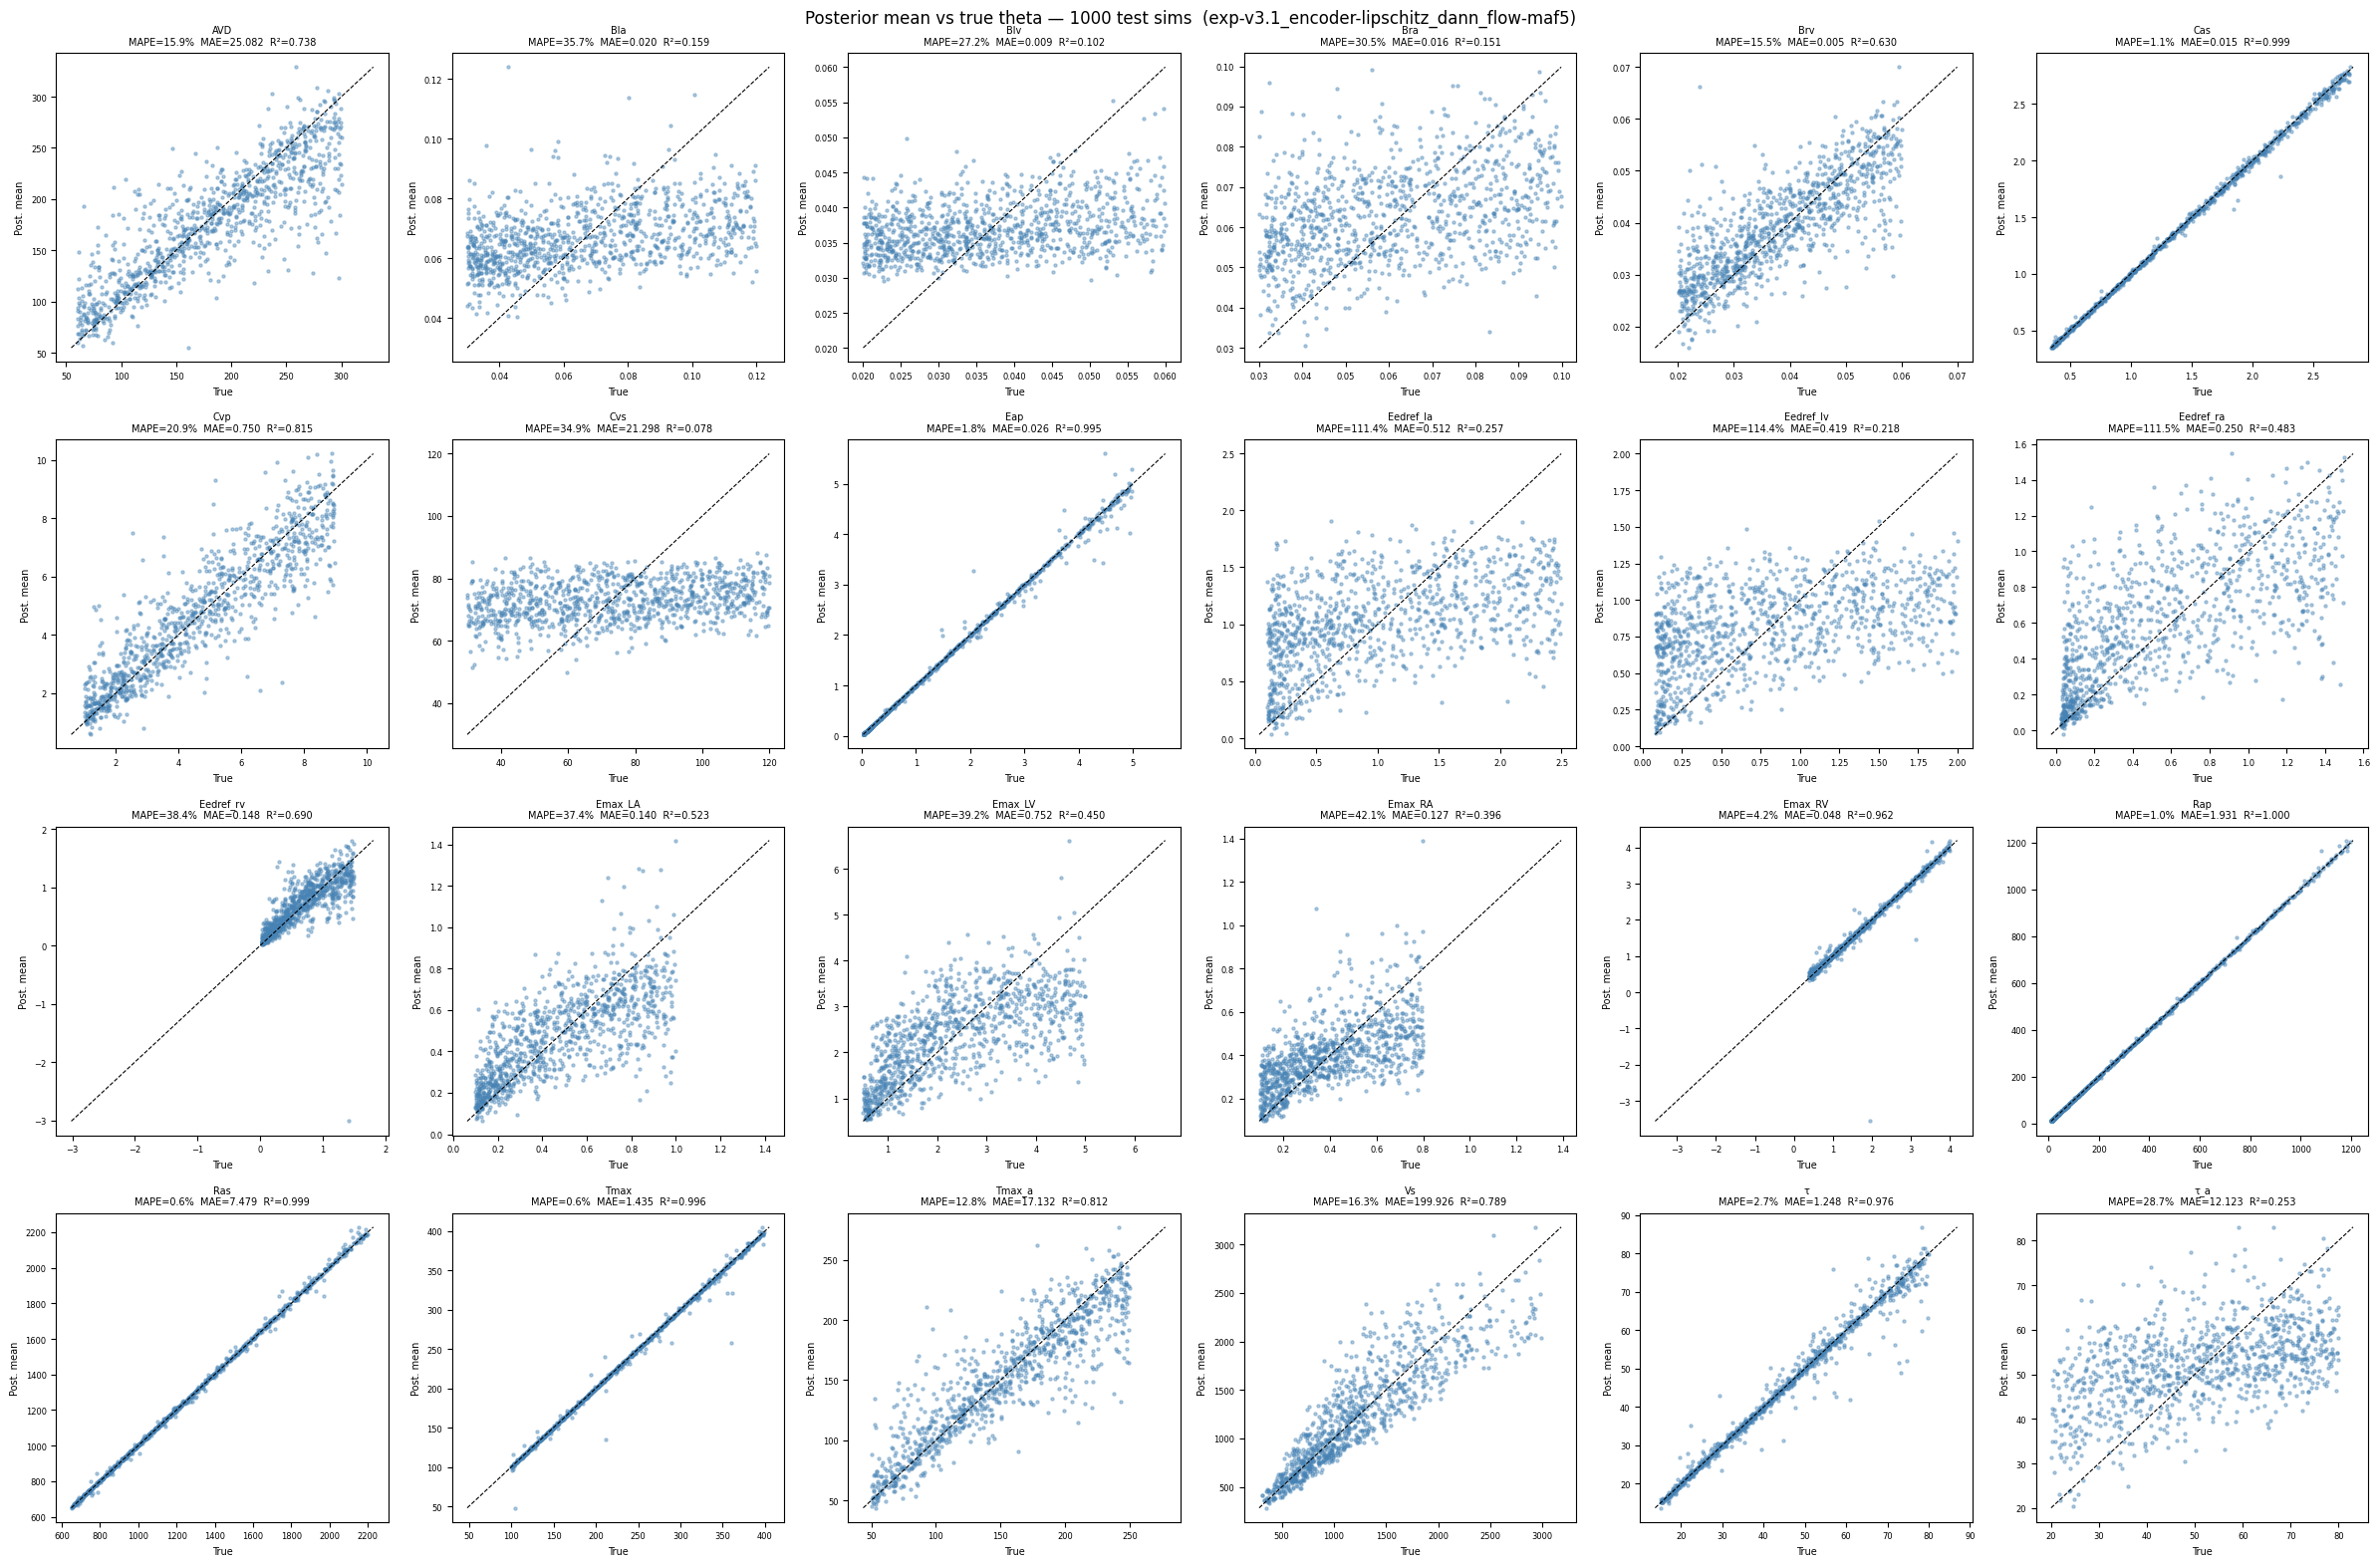


Param          MAPE        MAE      R²
--------------------------------------
AVD           15.9%    25.0818   0.738
Bla           35.7%     0.0203   0.159
Blv           27.2%     0.0090   0.102
Bra           30.5%     0.0159   0.151
Brv           15.5%     0.0052   0.630
Cas            1.1%     0.0149   0.999
Cvp           20.9%     0.7497   0.815
Cvs           34.9%    21.2979   0.078
Eap            1.8%     0.0263   0.995
Eedref_la    111.4%     0.5123   0.257
Eedref_lv    114.4%     0.4190   0.218
Eedref_ra    111.5%     0.2496   0.483
Eedref_rv     38.4%     0.1476   0.690
Emax_LA       37.4%     0.1399   0.523
Emax_LV       39.2%     0.7522   0.450
Emax_RA       42.1%     0.1266   0.396
Emax_RV        4.2%     0.0482   0.962
Rap            1.0%     1.9308   1.000
Ras            0.6%     7.4788   0.999
Tmax           0.6%     1.4345   0.996
Tmax_a        12.8%    17.1322   0.812
Vs            16.3%   199.9264   0.789
τ              2.7%     1.2476   0.976
τ_a           28.7%    1

In [14]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax   = axes[i // ncols, i % ncols]
    pred = sim_means[:, i]
    true = theta_np[:, i]
    lo   = min(true.min(), pred.min())
    hi   = max(true.max(), pred.max())
    ax.scatter(true, pred, s=5, alpha=0.4, color='steelblue', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    mape = np.mean(np.abs(pred - true) / (np.abs(true) + 1e-9)) * 100
    mae  = np.mean(np.abs(pred - true))
    r2   = pearsonr(true, pred)[0] ** 2
    ax.set_title(f'{name}\nMAPE={mape:.1f}%  MAE={mae:.3f}  R²={r2:.3f}', fontsize=7)
    ax.set_xlabel('True', fontsize=7); ax.set_ylabel('Post. mean', fontsize=7)
    ax.tick_params(labelsize=6)

for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')

fig.suptitle(f'Posterior mean vs true theta — {N_SIM_EVAL} test sims  ({RUN})', fontsize=12)
plt.tight_layout(); plt.show()

print(f'\n{"Param":<10} {"MAPE":>8} {"MAE":>10} {"R²":>7}')
print('-' * 38)
for i, name in enumerate(PARAM_KEYS_INFER):
    pred = sim_means[:, i]; true = theta_np[:, i]
    mape = np.mean(np.abs(pred - true) / (np.abs(true) + 1e-9)) * 100
    mae  = np.mean(np.abs(pred - true))
    r2   = pearsonr(true, pred)[0] ** 2
    print(f'{name:<10} {mape:>7.1f}%  {mae:>9.4f}  {r2:>6.3f}')

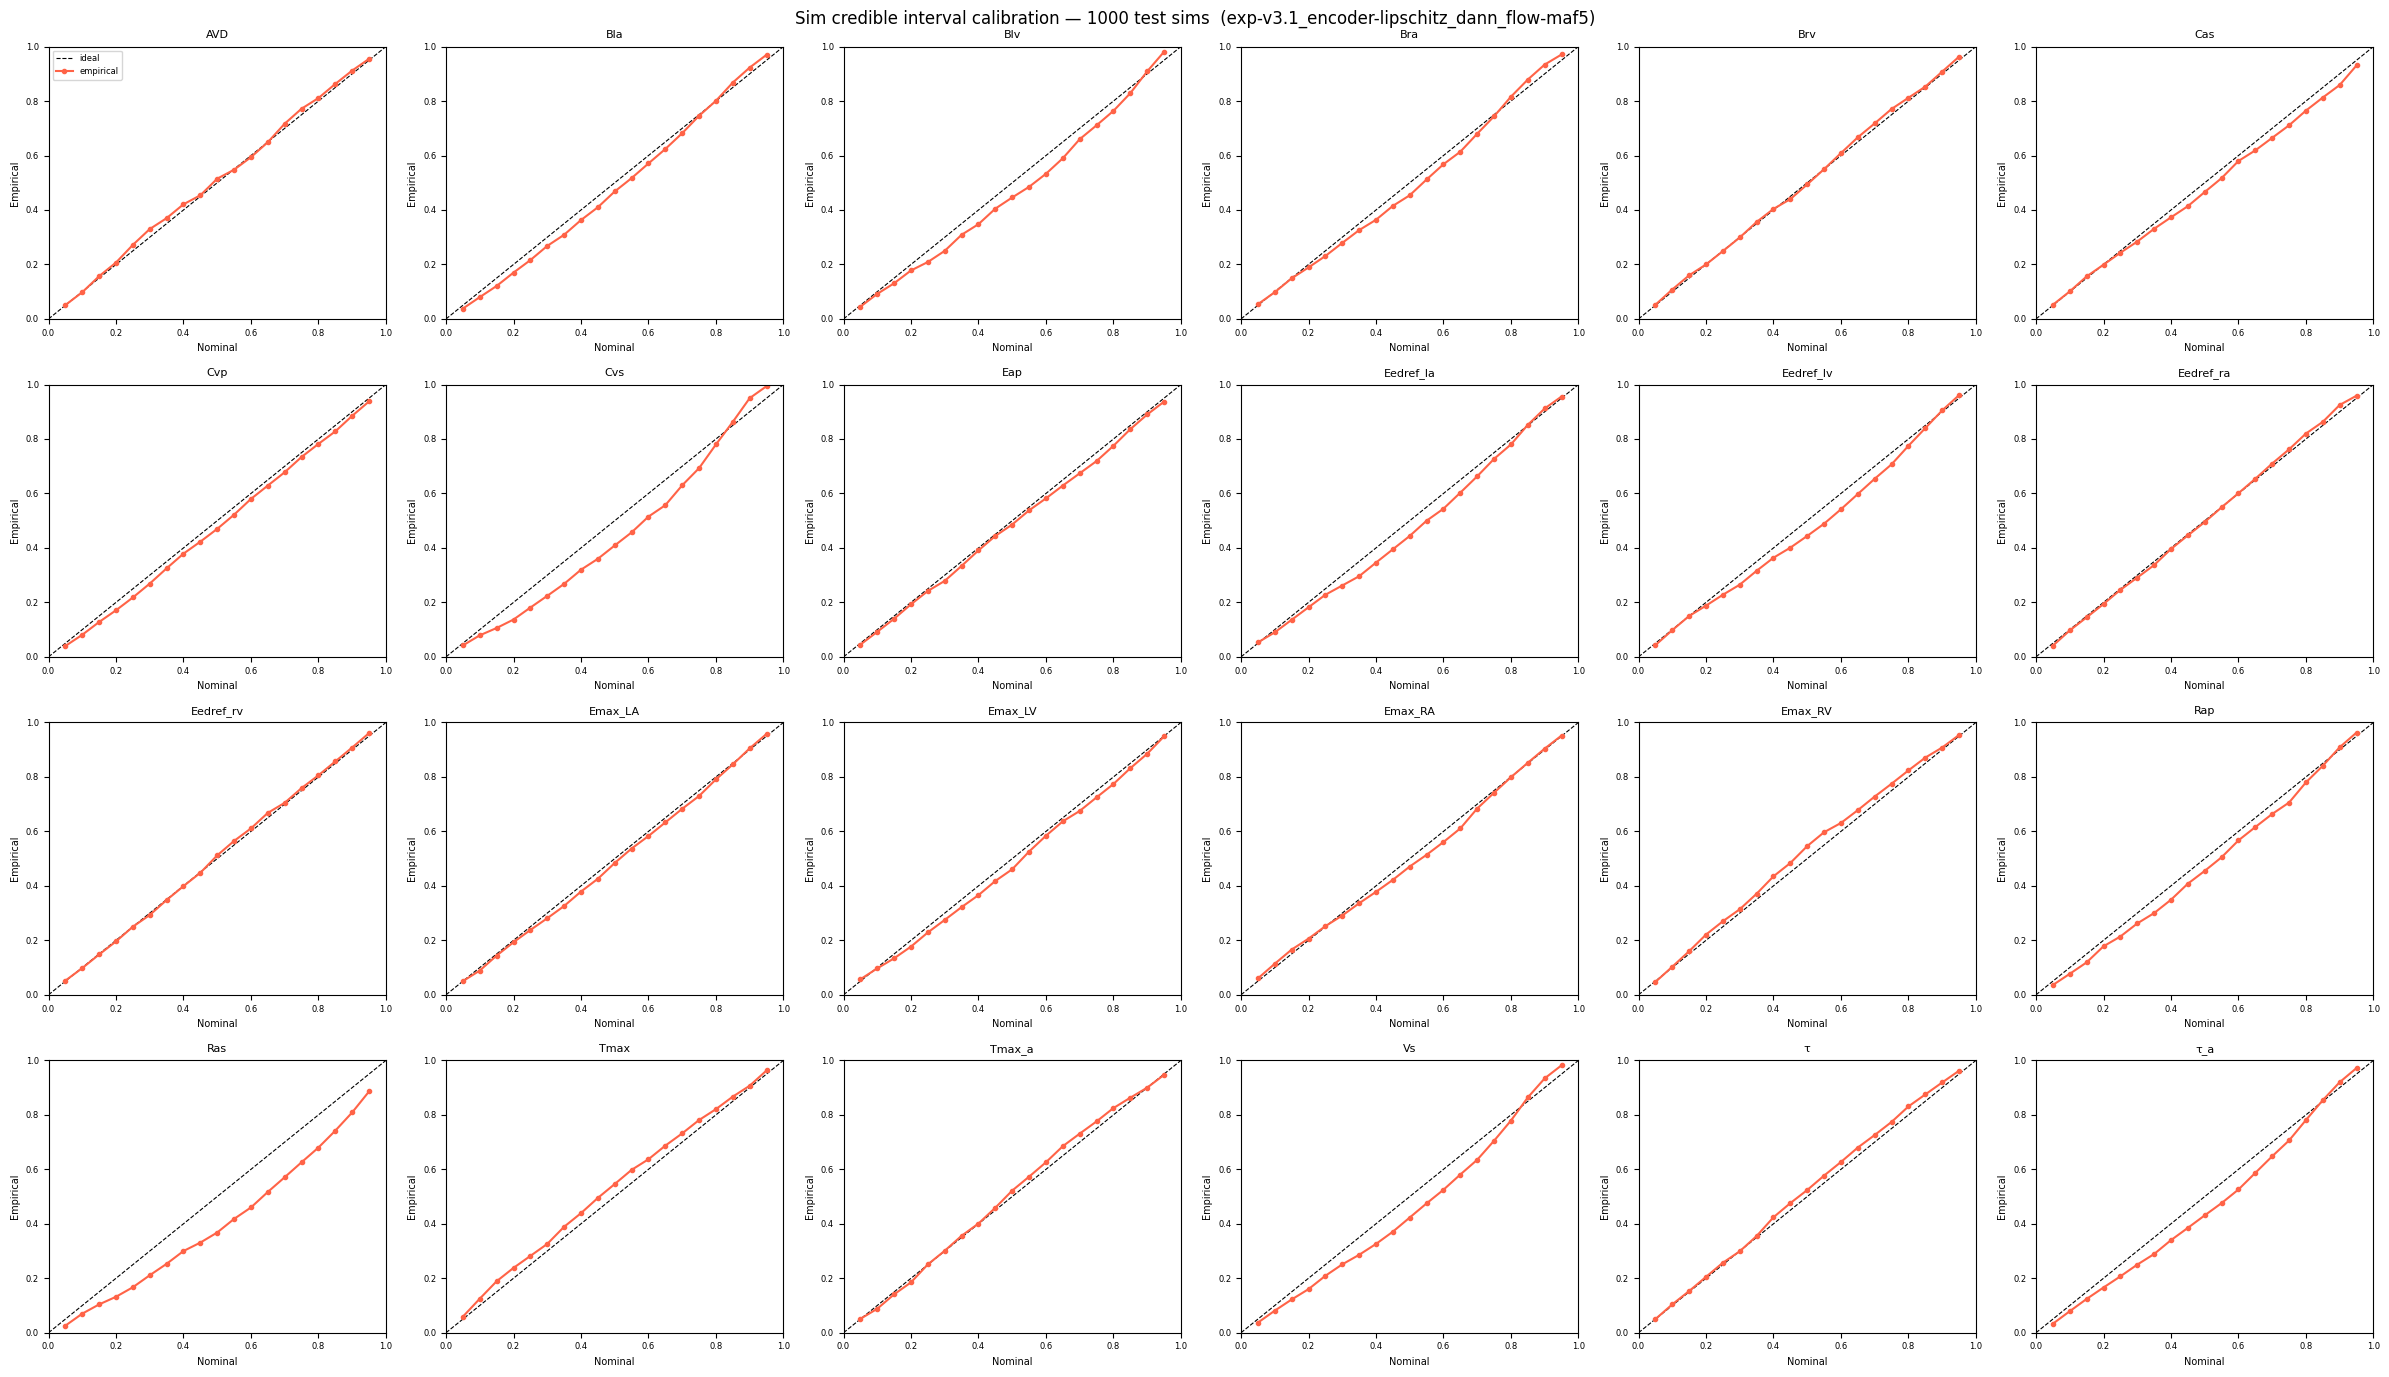

Coverage at 90% CI (ideal=0.90):
  mean=0.905  min=0.809 (Ras)  max=0.950 (Cvs)

Param        90% CI coverage
------------------------------
AVD                   0.912
Bla                   0.923
Blv                   0.909
Bra                   0.934
Brv                   0.908
Cas                   0.859
Cvp                   0.885
Cvs                   0.950
Eap                   0.890
Eedref_la             0.912
Eedref_lv             0.905
Eedref_ra             0.925
Eedref_rv             0.908
Emax_LA               0.905
Emax_LV               0.885
Emax_RA               0.904
Emax_RV               0.908
Rap                   0.909
Ras                   0.809
Tmax                  0.907
Tmax_a                0.900
Vs                    0.934
τ                     0.919
τ_a                   0.920


In [15]:
alphas_sim = np.linspace(0.05, 0.95, 19)
sim_s_np   = sim_samples.numpy()
coverage   = np.zeros((len(alphas_sim), len(PARAM_KEYS_INFER)))

for ai, alpha in enumerate(alphas_sim):
    lo_q = (1 - alpha) / 2 * 100
    hi_q = 100 - lo_q
    ci_lo  = np.percentile(sim_s_np, lo_q, axis=1)
    ci_hi  = np.percentile(sim_s_np, hi_q, axis=1)
    inside = (theta_np >= ci_lo) & (theta_np <= ci_hi)
    coverage[ai] = inside.mean(axis=0)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='ideal')
    ax.plot(alphas_sim, coverage[:, i], color='tomato', linewidth=1.5, marker='o', markersize=3, label='empirical')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('Nominal', fontsize=7); ax.set_ylabel('Empirical', fontsize=7)
    ax.tick_params(labelsize=6)
    if i == 0: ax.legend(fontsize=6)
for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')
fig.suptitle(f'Sim credible interval calibration — {N_SIM_EVAL} test sims  ({RUN})', fontsize=12)
plt.tight_layout(); plt.show()

cov_90 = coverage[alphas_sim.searchsorted(0.9), :]
print(f'Coverage at 90% CI (ideal=0.90):')
print(f'  mean={cov_90.mean():.3f}  min={cov_90.min():.3f} ({PARAM_KEYS_INFER[cov_90.argmin()]})  '
      f'max={cov_90.max():.3f} ({PARAM_KEYS_INFER[cov_90.argmax()]})')
print(f'\n{"Param":<10} {"90% CI coverage":>17}')
print('-' * 30)
for i, name in enumerate(PARAM_KEYS_INFER):
    flag = '  ← overconfident' if cov_90[i] < 0.80 else ('  ← underconfident' if cov_90[i] > 0.97 else '')
    print(f'{name:<10} {cov_90[i]:>16.3f}{flag}')